Nama: Syalista Galuh Nadira

NIM: 2702346361

**Video penjelasan**: https://drive.google.com/file/d/1T1a993SdSeOkSgvEIdZ8jVZkD76vntEC/view?usp=sharing

In [1]:
import pandas as pd
import numpy as np
!pip install google-play-scraper pandas
from google_play_scraper import reviews_all

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


# No. 1

Saya akan menggunakan data reviews dari app game **Vita Mahjong** sebagai dataset.

In [2]:
!pip install langdetect
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=a3361d8e2887e2ab2a1a0267653c6ef5a16aec1144dbefe5d0070c460ad114dc
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [3]:
DetectorFactory.seed = 0 # agar hasil deteksi bahasa konsisten

def detect_lang_safe(text):
  try:
    return detect(text)
  except:
    return "unknown"

app_id = "com.vitastudio.mahjong"

# SCRAPING
print(f"Game: {app_id}")

reviews = reviews_all(
    app_id,
    lang='en',  # target review berbahasa Inggris
)

df = pd.DataFrame(reviews)  # convert ke dataframe

# Deteksi bahasa dan filter hanya english
df['lang'] = df['content'].astype(str).apply(detect_lang_safe)
df = df[df['lang'] == 'en']

# Batasi 1000 data
df = df.head(1000)

print(f"\nScraping berhasil ✅ Berhasil mengumpulkan {len(df)} review berbahasa Inggris.")

Game: com.vitastudio.mahjong

Scraping berhasil ✅ Berhasil mengumpulkan 1000 review berbahasa Inggris.


In [4]:
print("Rating Distribution:")
print(df['score'].value_counts().sort_index())

# Save ke CSV
df.to_csv('vitamahjong_reviews.csv', index=False)
print("\nData disimpan sebagai 'vitamahjong_reviews.csv'")

# Sample reviews
print("\nSample Reviews:")
for i in range(min(3, len(df))):
  print(f"{df['score'].iloc[i]}⭐️: {df['content'].iloc[i]}")

Rating Distribution:
score
1    159
2     54
3     61
4     54
5    672
Name: count, dtype: int64

Data disimpan sebagai 'vitamahjong_reviews.csv'

Sample Reviews:
5⭐️: Love this game
3⭐️: absolutely brilliant game. only problem I've had is, i accidentally uninstalled the game and when I reinstalled im on the same level but I've lost all my daily achievements which was up to date and I've lost all my tournament wins which was 65!! is there anyway I can recover them????....... you might also want to look what ads your using, 'shein' & 'aliexpress' bullying you to click and open the app! which can be almost impossible to exit and now they are appearing 3/4 times within one round!!
5⭐️: great for the mind. I am able to relax and focus.


---

# No. 2

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud

In [6]:
# Load data
df = pd.read_csv('vitamahjong_reviews.csv')

#### Dataset structure

In [7]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,lang
0,3a14017f-7f2c-4c12-8a83-1e38df1ad842,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Love this game,5,0,NaN,2025-11-11 23:10:30,NaN,NaN,NaN,en
1,d77de371-179a-49a2-b05b-cdf759a0bd64,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,absolutely brilliant game. only problem I've h...,3,1,2.64.3,2025-11-11 22:53:44,I'm so glad you love the game! I recommend rea...,2025-10-04 04:02:16,2.64.3,en
2,8a96e522-acb0-45e6-8892-b10672f6378a,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,great for the mind. I am able to relax and focus.,5,0,2.64.3,2025-11-11 22:53:01,NaN,NaN,2.64.3,en
3,9c832bb6-4f01-4110-92a2-e470e2e00e02,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"I like the game, but there's way too many adds...",3,0,2.64.3,2025-11-11 22:48:11,NaN,NaN,2.64.3,en
4,6b5ccca2-6f0c-4052-ad61-fd7ed6da4073,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,EXCELANT PLAY WITH THIS GAME RILAX MIND WITH T...,5,0,2.64.3,2025-11-11 22:47:01,NaN,NaN,2.64.3,en


In [8]:
df.shape

(1000, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              1000 non-null   object
 1   userName              1000 non-null   object
 2   userImage             1000 non-null   object
 3   content               1000 non-null   object
 4   score                 1000 non-null   int64 
 5   thumbsUpCount         1000 non-null   int64 
 6   reviewCreatedVersion  828 non-null    object
 7   at                    1000 non-null   object
 8   replyContent          174 non-null    object
 9   repliedAt             174 non-null    object
 10  appVersion            828 non-null    object
 11  lang                  1000 non-null   object
dtypes: int64(2), object(10)
memory usage: 93.9+ KB


In [10]:
# Description of numerical variables
df.describe()

,score,thumbsUpCount
count,1000.000000,1000.000000
mean,4.026000,1.183000
std,1.543278,26.629883
min,1.000000,0.000000
25%,3.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,836.000000


In [11]:
# Description of categorical variables
df.describe(include='O')

,reviewId,userName,userImage,content,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,lang
count,1000,1000,1000,1000,828,1000,174,174,828,1000
unique,1000,1,1,959,27,999,169,174,27,1
top,29a5d1a5-c359-440e-8fae-cbb2e1bf8fce,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Great game,2.64.3,2025-11-06 00:27:24,Thank you for the positive vibes! Anything you...,2025-10-04 04:02:16,2.64.3,en
freq,1,1000,1000,8,439,2,3,1,439,1000


In [12]:
# Missing values
print(df['content'].isna().sum())
print(df['score'].isna().sum())

0
0


#### Distribusi rating

DISTRIBUSI RATING:

1⭐️: 159 reviews (15.9%)
2⭐️: 54 reviews (5.4%)
3⭐️: 61 reviews (6.1%)
4⭐️: 54 reviews (5.4%)
5⭐️: 672 reviews (67.2%)


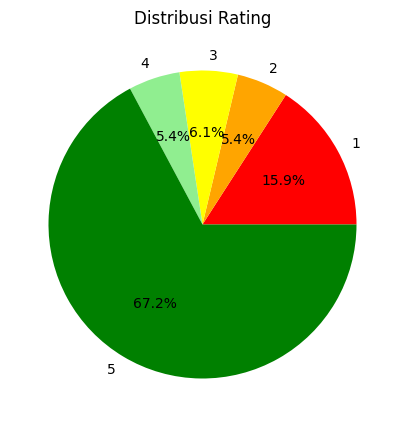

In [13]:
print("DISTRIBUSI RATING:\n")

rating_counts = df['score'].value_counts().sort_index() # Jumlah review untuk setiap rating dan sort by rating
for rating, count in rating_counts.items():
  percentage = (count / len(df)) * 100
  print(f"{rating}⭐️: {count} reviews ({percentage:.1f}%)") # Rating, jumlah review, percentage

colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']
plt.figure(figsize=(5, 5))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Distribusi Rating')
plt.show()

#### Kata dominan per rating

In [14]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [16]:
print("KATA DOMINAN PER RATING:")

def clean_words(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    # Hapus tanda baca hanya untuk analisis ini
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    words = text.split()
    return [word for word in words if len(word) > 2]

for rating in range(1, 6):
    # Filter by rating
    rating_reviews = df[df['score'] == rating]['content']

    # Collect all words
    all_words = []
    for review in rating_reviews:
        all_words.extend(clean_words(review))

    # Frekuensi muncul
    word_freq = Counter(all_words)

    # Kata teratas (kecuali kata yg sering muncul)
    common_words = set(stopwords.words('english'))
    top_words = [(word, freq) for word, freq in word_freq.most_common(30)
                 if word not in common_words][:10]

    print(f"\n{rating}⭐️ - 10 teratas kata dominan:")
    for i, (word, freq) in enumerate(top_words, 1):
        print(f" {i:2d}. '{word}': {freq} kali")

KATA DOMINAN PER RATING:

1⭐️ - 10 teratas kata dominan:
  1. 'game': 148 kali
  2. 'ads': 97 kali
  3. 'dont': 27 kali
  4. 'like': 26 kali
  5. 'play': 26 kali
  6. 'playing': 23 kali
  7. 'get': 23 kali
  8. 'app': 17 kali
  9. 'many': 16 kali
 10. 'time': 16 kali

2⭐️ - 10 teratas kata dominan:
  1. 'game': 44 kali
  2. 'ads': 42 kali
  3. 'every': 14 kali
  4. 'play': 14 kali
  5. 'app': 13 kali
  6. 'get': 13 kali
  7. 'level': 11 kali
  8. 'mahjong': 10 kali
  9. 'dont': 10 kali
 10. 'levels': 8 kali

3⭐️ - 10 teratas kata dominan:
  1. 'game': 68 kali
  2. 'ads': 33 kali
  3. 'play': 15 kali
  4. 'like': 10 kali
  5. 'get': 10 kali
  6. 'way': 9 kali
  7. 'great': 9 kali
  8. 'level': 8 kali
  9. 'app': 8 kali
 10. 'tiles': 8 kali

4⭐️ - 10 teratas kata dominan:
  1. 'game': 49 kali
  2. 'ads': 21 kali
  3. 'tiles': 9 kali
  4. 'love': 9 kali
  5. 'like': 9 kali
  6. 'undo': 9 kali
  7. 'play': 8 kali
  8. 'get': 8 kali
  9. 'games': 7 kali
 10. 'fun': 7 kali

5⭐️ - 10 teratas 

#### WordCloud kata dominan

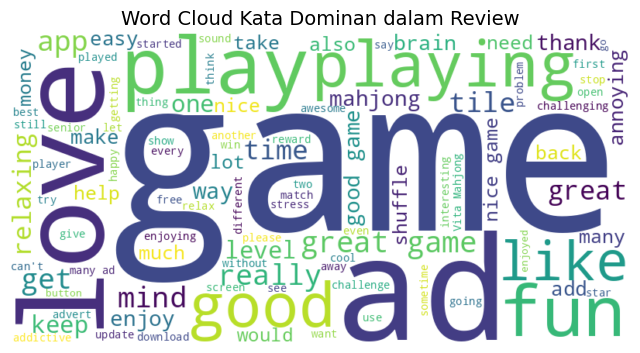

In [17]:
text = " ".join(df['content'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    stopwords=set(stopwords.words('english')),
    colormap='viridis'
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Kata Dominan dalam Review', fontsize=14)
plt.show()

#### Panjang rata-rata kata review

Rata-rata panjang review: 15.8 kata

Rata-rata panjang review per rating:
1⭐️: 25.6 kata
2⭐️: 35.5 kata
3⭐️: 31.5 kata
4⭐️: 25.3 kata
5⭐️: 9.7 kata


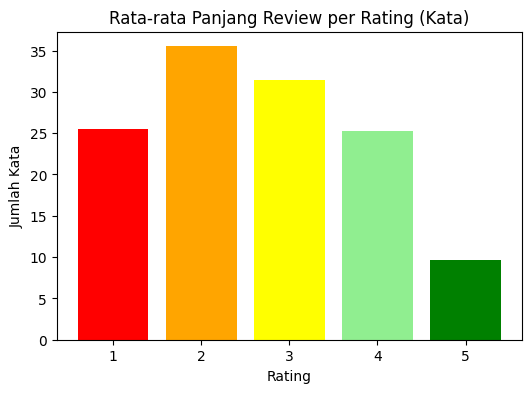

In [18]:
# Cek panjang rata-rata review keseluruhan
avg_length_all = df['content'].apply(lambda x: len(str(x).split())).mean()
print(f"Rata-rata panjang review: {avg_length_all:.1f} kata")

# Cek panjang rata-rata review per rating
print(f"\nRata-rata panjang review per rating:")
for rating in range(1, 6):
  rating_reviews = df[df['score'] == rating]['content']
  avg_length = rating_reviews.apply(lambda x: len(str(x).split())).mean()
  print(f"{rating}⭐️: {avg_length:.1f} kata")

# Plot
plt.figure(figsize=(6, 4))
plt.bar(
    range(1, 6),
    [df[df['score'] == r]['content'].apply(lambda x: len(str(x).split())).mean() for r in range(1, 6)],
    color=['red', 'orange', 'yellow', 'lightgreen', 'green']
)
plt.title('Rata-rata Panjang Review per Rating (Kata)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Kata')
plt.show()

#### Panjang rata-rata kalimat review

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Rata-rata panjang review: 1.7 kalimat

Rata-rata panjang review per rating:
1⭐️: 2.3 kalimat
2⭐️: 3.1 kalimat
3⭐️: 2.7 kalimat
4⭐️: 2.1 kalimat
5⭐️: 1.4 kalimat


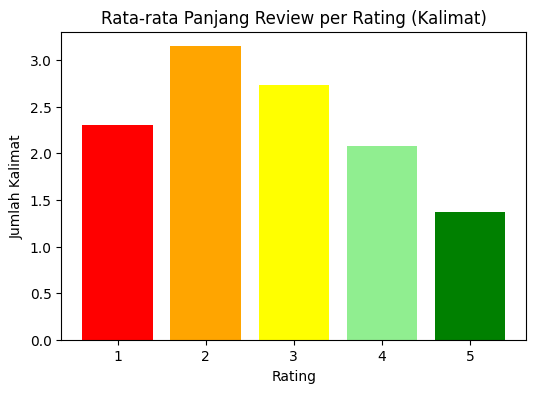

In [19]:
nltk.download('punkt_tab')

avg_sentences = df['content'].apply(lambda x: len(nltk.sent_tokenize(str(x)))).mean()

print(f"Rata-rata panjang review: {avg_sentences:.1f} kalimat")

print(f"\nRata-rata panjang review per rating:")
for rating in range(1, 6):
  rating_reviews = df[df['score'] == rating]['content']
  avg_sent = rating_reviews.apply(lambda x: len(nltk.sent_tokenize(str(x)))).mean()
  print(f"{rating}⭐️: {avg_sent:.1f} kalimat")

# Plot
plt.figure(figsize=(6, 4))
plt.bar(
    range(1, 6),
    [df[df['score'] == r]['content'].apply(lambda x: len(nltk.sent_tokenize(str(x)))).mean() for r in range(1, 6)],
    color=['red', 'orange', 'yellow', 'lightgreen', 'green']
)
plt.title('Rata-rata Panjang Review per Rating (Kalimat)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Kalimat')
plt.show()

---

# No. 3

#### Split Data

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df['content'],
    df['score'],
    test_size=0.2,
    random_state=42,
    stratify=df['score']
)

print(f"Train size: {len(x_train)}, Test size: {len(x_test)}")

Train size: 800, Test size: 200


#### **Preprocessing**

In [21]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
stop_words = set(stopwords.words('english'))

def cleansing(text_series):
    text_clean = text_series.str.lower() # case folding
    text_clean = [re.sub(r"\d+", "", t) for t in text_clean]
    text_clean = [re.sub(r"[^\w]", " ", t) for t in text_clean]
    text_clean = [re.sub(r"\s+", " ", t) for t in text_clean]
    return text_clean

# cleaning
x_train_clean = cleansing(x_train)
x_test_clean = cleansing(x_test)

# tokenizing
token_train = [word_tokenize(t) for t in x_train_clean]
token_test = [word_tokenize(t) for t in x_test_clean]

# remove stopwords
filtered_train = [[w for w in sent if w not in stop_words] for sent in token_train]
filtered_test = [[w for w in sent if w not in stop_words] for sent in token_test]

print(filtered_train[0][:15])

['happy', 'ads']


---

# No. 4 - 7

#### **Text Representation**

In [23]:
!pip install gensim
import gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 12.1 MB/s eta 0:00:00


## Tanpa SMOTE Oversampling

### **TF-IDF**

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

tfidf = TfidfVectorizer(
    max_features=3000,   # batasi fitur ke 3000 kata paling penting
    ngram_range=(1,2),   # unigram + bigram
    min_df=2              # hanya ambil kata yang muncul minimal di 2 dokumen
)

# Fit dan transform data train/test
X_train_tfidf = tfidf.fit_transform(x_train)
X_test_tfidf  = tfidf.transform(x_test)

print("===== TF-IDF Representation =====")
print("Shape (train):", X_train_tfidf.shape)
print("Shape (test):", X_test_tfidf.shape)
print("Contoh vocab:", list(tfidf.vocabulary_.items())[:15])


===== TF-IDF Representation =====
Shape (train): (800, 1909)
Shape (test): (200, 1909)
Contoh vocab: [('happy', np.int64(696)), ('there', np.int64(1539)), ('is', np.int64(777)), ('no', np.int64(1048)), ('ads', np.int64(38)), ('there is', np.int64(1541)), ('is no', np.int64(791)), ('no ads', np.int64(1049)), ('yes', np.int64(1858)), ('enjoyed', np.int64(454)), ('this', np.int64(1558)), ('game', np.int64(574)), ('to', np.int64(1596)), ('exercise', np.int64(488)), ('mind', np.int64(992))]


#### Train & evaluasi model SVM TF-IDF

In [25]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm_tfidf = LinearSVC(random_state=42)
svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = svm_tfidf.predict(X_test_tfidf)

print("===== Linear SVM (TF-IDF) =====")
print(classification_report(y_test, y_pred_tfidf))

===== Linear SVM (TF-IDF) =====
              precision    recall  f1-score   support

           1       0.44      0.56      0.49        32
           2       0.33      0.18      0.24        11
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00        11
           5       0.87      0.93      0.90       134

    accuracy                           0.72       200
   macro avg       0.33      0.33      0.33       200
weighted avg       0.67      0.72      0.69       200



#### Train & evaluasi model Random Forest TF-IDF

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_tfidf = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    random_state=42
)
rf_tfidf.fit(X_train_tfidf, y_train)

y_pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf)

print("===== Random Forest (TF-IDF) =====")
print(classification_report(y_test, y_pred_rf_tfidf))

===== Random Forest (TF-IDF) =====
              precision    recall  f1-score   support

           1       0.39      0.38      0.38        32
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00        11
           5       0.77      0.97      0.86       134

    accuracy                           0.71       200
   macro avg       0.23      0.27      0.25       200
weighted avg       0.58      0.71      0.64       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### **Skipgram Word2Vec**

In [28]:
from gensim.models import Word2Vec

model_skipgram = Word2Vec(
    sentences=filtered_train,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,  # skipgram
    workers=4,
    seed=42
)

# ambil rata-rata embedding tiap dokumen
def avg_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(model.vector_size)

# ubah dokumen train & test jadi vektor rata-rata
X_train_w2v = np.array([avg_vector(tokens, model_skipgram) for tokens in filtered_train])
X_test_w2v  = np.array([avg_vector(tokens, model_skipgram) for tokens in filtered_test])

print("Word2Vec train shape:", X_train_w2v.shape)
print("Word2Vec test shape :", X_test_w2v.shape)
print("Vocab size:", len(model_skipgram.wv))
print("Sample words:", list(model_skipgram.wv.key_to_index.keys())[:15])

Word2Vec train shape: (800, 100)
Word2Vec test shape : (200, 100)
Vocab size: 685
Sample words: ['game', 'ads', 'love', 'play', 'great', 'good', 'fun', 'playing', 'like', 'get', 'mind', 'really', 'ad', 'nice', 'app']


#### Train & evaluasi model SVM Word2Vec

In [29]:
svm_w2v = LinearSVC(random_state=42)
svm_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = svm_w2v.predict(X_test_w2v)

print("===== Linear SVM (Word2Vec Skipgram) =====")
print(classification_report(y_test, y_pred_w2v))


===== Linear SVM (Word2Vec Skipgram) =====
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        32
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00        11
           5       0.67      1.00      0.80       134

    accuracy                           0.67       200
   macro avg       0.13      0.20      0.16       200
weighted avg       0.45      0.67      0.54       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Train & evaluasi model Random Forest Word2Vec

In [30]:
rf_w2v = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    random_state=42
)
rf_w2v.fit(X_train_w2v, y_train)

y_pred_rf_w2v = rf_w2v.predict(X_test_w2v)

print("===== Random Forest (Word2Vec Skipgram) =====")
print(classification_report(y_test, y_pred_rf_w2v))

===== Random Forest (Word2Vec Skipgram) =====
              precision    recall  f1-score   support

           1       0.50      0.41      0.45        32
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00        11
           5       0.75      0.96      0.84       134

    accuracy                           0.71       200
   macro avg       0.25      0.27      0.26       200
weighted avg       0.58      0.71      0.63       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Dengan SMOTE Oversampling

In [31]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)

**Apply SMOTE**

In [32]:
# TF-IDF
X_train_tfidf_sm, y_train_tfidf_sm = smote.fit_resample(X_train_tfidf, y_train)
print("TF-IDF sebelum SMOTE:", Counter(y_train))
print("TF-IDF sesudah SMOTE:", Counter(y_train_tfidf_sm))

# Word2Vec Skipgram
X_train_w2v_sm, y_train_w2v_sm = smote.fit_resample(X_train_w2v, y_train)
print("\nWord2Vec sebelum SMOTE:", Counter(y_train))
print("Word2Vec sesudah SMOTE:", Counter(y_train_w2v_sm))

TF-IDF sebelum SMOTE: Counter({5: 538, 1: 127, 3: 49, 2: 43, 4: 43})
TF-IDF sesudah SMOTE: Counter({5: 538, 3: 538, 2: 538, 1: 538, 4: 538})

Word2Vec sebelum SMOTE: Counter({5: 538, 1: 127, 3: 49, 2: 43, 4: 43})
Word2Vec sesudah SMOTE: Counter({5: 538, 3: 538, 2: 538, 1: 538, 4: 538})


#### Train & evaluasi model TF-IDF

In [33]:
# TF-IDF (SVM)
svm_tfidf_sm = LinearSVC(random_state=42)
svm_tfidf_sm.fit(X_train_tfidf_sm, y_train_tfidf_sm)
pred_tfidf_svm_sm = svm_tfidf_sm.predict(X_test_tfidf)

print("===== SVM (TF-IDF + SMOTE) =====")
print(classification_report(y_test, pred_tfidf_svm_sm, digits=2))

===== SVM (TF-IDF + SMOTE) =====
              precision    recall  f1-score   support

           1       0.50      0.53      0.52        32
           2       0.30      0.27      0.29        11
           3       0.14      0.17      0.15        12
           4       0.00      0.00      0.00        11
           5       0.90      0.90      0.90       134

    accuracy                           0.71       200
   macro avg       0.37      0.37      0.37       200
weighted avg       0.71      0.71      0.71       200



In [34]:
# TF-IDF (Random Forest)
rf_tfidf_sm = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_tfidf_sm.fit(X_train_tfidf_sm, y_train_tfidf_sm)
pred_tfidf_rf_sm = rf_tfidf_sm.predict(X_test_tfidf)

print("===== Random Forest (TF-IDF + SMOTE) =====")
print(classification_report(y_test, pred_tfidf_rf_sm, digits=2))

===== Random Forest (TF-IDF + SMOTE) =====
              precision    recall  f1-score   support

           1       0.41      0.66      0.51        32
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00        11
           5       0.87      0.93      0.90       134

    accuracy                           0.72       200
   macro avg       0.26      0.32      0.28       200
weighted avg       0.65      0.72      0.68       200



#### Train & evaluasi model Word2Vec

In [35]:
# Word2Vec (SVM)
svm_w2v_sm = LinearSVC(random_state=42)
svm_w2v_sm.fit(X_train_w2v_sm, y_train_w2v_sm)
pred_w2v_svm_sm = svm_w2v_sm.predict(X_test_w2v)

print("\n===== SVM (Word2Vec + SMOTE) =====")
print(classification_report(y_test, pred_w2v_svm_sm, digits=2))


===== SVM (Word2Vec + SMOTE) =====
              precision    recall  f1-score   support

           1       0.39      0.22      0.28        32
           2       0.14      0.45      0.21        11
           3       0.08      0.25      0.12        12
           4       0.05      0.09      0.06        11
           5       0.86      0.57      0.68       134

    accuracy                           0.46       200
   macro avg       0.30      0.32      0.27       200
weighted avg       0.66      0.46      0.53       200



In [36]:
# Word2Vec (Random Forest)
rf_w2v_sm = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_w2v_sm.fit(X_train_w2v_sm, y_train_w2v_sm)
pred_w2v_rf_sm = rf_w2v_sm.predict(X_test_w2v)

print("\n===== Random Forest (Word2Vec + SMOTE) =====")
print(classification_report(y_test, pred_w2v_rf_sm, digits=2))


===== Random Forest (Word2Vec + SMOTE) =====
              precision    recall  f1-score   support

           1       0.47      0.62      0.53        32
           2       0.20      0.09      0.12        11
           3       0.00      0.00      0.00        12
           4       0.08      0.09      0.09        11
           5       0.87      0.84      0.85       134

    accuracy                           0.67       200
   macro avg       0.32      0.33      0.32       200
weighted avg       0.67      0.67      0.67       200



## **Summary**

In [43]:
# =======================
# 1. Summary (tanpa) SMOTE)
# =======================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_no_smote = []

# TF-IDF - SVM
results_no_smote.append({
    'Text Representation': 'TF-IDF',
    'Algorithm': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred_tfidf),
    'Precision': precision_score(y_test, y_pred_tfidf, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_tfidf, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_tfidf, average='weighted', zero_division=0)
})

# TF-IDF - Random Forest
results_no_smote.append({
    'Text Representation': 'TF-IDF',
    'Algorithm': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf_tfidf),
    'Precision': precision_score(y_test, y_pred_rf_tfidf, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf_tfidf, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_rf_tfidf, average='weighted', zero_division=0)
})

# Word2Vec - SVM
results_no_smote.append({
    'Text Representation': 'Word2Vec',
    'Algorithm': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred_w2v),
    'Precision': precision_score(y_test, y_pred_w2v, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_w2v, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_w2v, average='weighted', zero_division=0)
})

# Word2Vec - Random Forest
results_no_smote.append({
    'Text Representation': 'Word2Vec',
    'Algorithm': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf_w2v),
    'Precision': precision_score(y_test, y_pred_rf_w2v, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf_w2v, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_rf_w2v, average='weighted', zero_division=0)
})

df_no_smote = pd.DataFrame(results_no_smote)
print("===== Summary TANPA SMOTE =====")
print(df_no_smote.to_markdown(index=False))

# =======================
# 2. Summary DENGAN SMOTE
# =======================
results_smote = []

# TF-IDF - SVM
results_smote.append({
    'Text Representation': 'TF-IDF',
    'Algorithm': 'SVM (SMOTE)',
    'Accuracy': accuracy_score(y_test, pred_tfidf_svm_sm),
    'Precision': precision_score(y_test, pred_tfidf_svm_sm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, pred_tfidf_svm_sm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, pred_tfidf_svm_sm, average='weighted', zero_division=0)
})

# TF-IDF - Random Forest
results_smote.append({
    'Text Representation': 'TF-IDF',
    'Algorithm': 'Random Forest (SMOTE)',
    'Accuracy': accuracy_score(y_test, pred_tfidf_rf_sm),
    'Precision': precision_score(y_test, pred_tfidf_rf_sm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, pred_tfidf_rf_sm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, pred_tfidf_rf_sm, average='weighted', zero_division=0)
})

# Word2Vec - SVM
results_smote.append({
    'Text Representation': 'Word2Vec',
    'Algorithm': 'SVM (SMOTE)',
    'Accuracy': accuracy_score(y_test, pred_w2v_svm_sm),
    'Precision': precision_score(y_test, pred_w2v_svm_sm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, pred_w2v_svm_sm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, pred_w2v_svm_sm, average='weighted', zero_division=0)
})

# Word2Vec - Random Forest
results_smote.append({
    'Text Representation': 'Word2Vec',
    'Algorithm': 'Random Forest (SMOTE)',
    'Accuracy': accuracy_score(y_test, pred_w2v_rf_sm),
    'Precision': precision_score(y_test, pred_w2v_rf_sm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, pred_w2v_rf_sm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, pred_w2v_rf_sm, average='weighted', zero_division=0)
})

df_smote = pd.DataFrame(results_smote)
print("\n===== Summary DENGAN SMOTE =====")
print(df_smote.to_markdown(index=False))

===== Summary TANPA SMOTE =====
| Text Representation   | Algorithm     |   Accuracy |   Precision |   Recall |   F1-score |
|:----------------------|:--------------|-----------:|------------:|---------:|-----------:|
| TF-IDF                | SVM           |       0.72 |    0.673648 |     0.72 |   0.693874 |
| TF-IDF                | Random Forest |       0.71 |    0.57732  |     0.71 |   0.63587  |
| Word2Vec              | SVM           |       0.67 |    0.4489   |     0.67 |   0.537605 |
| Word2Vec              | Random Forest |       0.71 |    0.579595 |     0.71 |   0.634786 |

===== Summary DENGAN SMOTE =====
| Text Representation   | Algorithm             |   Accuracy |   Precision |   Recall |   F1-score |
|:----------------------|:----------------------|-----------:|------------:|---------:|-----------:|
| TF-IDF                | SVM (SMOTE)           |      0.71  |    0.709583 |    0.71  |   0.709616 |
| TF-IDF                | Random Forest (SMOTE) |      0.725 |    0.64686


Sebelum SMOTE, model dengan representasi **TF-IDF** jelas menunjukkan performa lebih unggul dibanding Word2Vec.  
- **SVM dengan TF-IDF** mencapai akurasi dan F1-score tertinggi (0.72 dan 0.69), menandakan model ini paling seimbang dalam mengenali kelas mayoritas maupun minoritas.  
- **Random Forest dengan TF-IDF** masih kompetitif, tapi precision-nya lebih rendah — menunjukkan kecenderungan overfitting pada kelas dominan.  
Sebaliknya, dua model berbasis **Word2Vec** (SVM dan RF) menghasilkan performa lebih rendah, karena representasi berbasis vektor kata kurang mampu menangkap perbedaan antar label ketika data tidak seimbang.

Setelah diterapkan **SMOTE**, efeknya bervariasi antar model.  
- Untuk **TF-IDF**, baik SVM maupun Random Forest menunjukkan peningkatan stabil — terutama Random Forest yang naik cukup signifikan di F1-score (dari 0.63 ke 0.68).  
Artinya, penyeimbangan kelas membantu model berbasis pohon memahami pola minoritas lebih baik.  
- Namun pada **Word2Vec**, hasilnya berlawanan: performa SVM justru turun drastis (akurasi 0.46), menandakan SMOTE menambah noise pada embedding yang berbasis distribusi kata.  
Random Forest dengan Word2Vec sedikit membaik, tapi tetap tertinggal jauh dari TF-IDF.

Secara keseluruhan, kombinasi **TF-IDF + SVM** terbukti paling optimal dan konsisten, baik sebelum maupun sesudah oversampling, dengan performa tinggi dan stabil di seluruh metrik evaluasi.

---

## **Hyperparameter Tuning**

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import classification_report

# ===== Linear SVM (TF-IDF + SMOTE) =====

param_dist_svm_tfidf = {
    'C': uniform(0.01, 10),
    'class_weight': [None, 'balanced'],
    'max_iter': randint(1000, 6000)
}

rand_svm_tfidf = RandomizedSearchCV(
    LinearSVC(random_state=42),
    param_distributions=param_dist_svm_tfidf,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_svm_tfidf.fit(X_train_tfidf_sm, y_train_tfidf_sm)
print("Best SVM (TF-IDF) params:", rand_svm_tfidf.best_params_)
print("Best CV score:", rand_svm_tfidf.best_score_)

best_svm_tfidf_rand = rand_svm_tfidf.best_estimator_
y_pred_svm_tfidf_rand = best_svm_tfidf_rand.predict(X_test_tfidf)
print("\n===== Tuned (Randomized) SVM (TF-IDF + SMOTE) =====")
print(classification_report(y_test, y_pred_svm_tfidf_rand, digits=2))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best SVM (TF-IDF) params: {'C': np.float64(2.4202546602601167), 'class_weight': 'balanced', 'max_iter': 2478}
Best CV score: 0.9761453771495351

===== Tuned (Randomized) SVM (TF-IDF + SMOTE) =====
              precision    recall  f1-score   support

           1       0.45      0.47      0.46        32
           2       0.33      0.27      0.30        11
           3       0.14      0.17      0.15        12
           4       0.00      0.00      0.00        11
           5       0.89      0.90      0.89       134

    accuracy                           0.70       200
   macro avg       0.36      0.36      0.36       200
weighted avg       0.70      0.70      0.70       200



In [48]:
# ===== Random Forest (TF-IDF + SMOTE) =====

param_dist_rf_tfidf = {
    'n_estimators': randint(100, 400),
    'max_depth': [None, 10, 30, 50, 70],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rand_rf_tfidf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf_tfidf,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_rf_tfidf.fit(X_train_tfidf_sm, y_train_tfidf_sm)
print("Best RF (TF-IDF) params:", rand_rf_tfidf.best_params_)
print("Best CV score:", rand_rf_tfidf.best_score_)

best_rf_tfidf_rand = rand_rf_tfidf.best_estimator_
y_pred_rf_tfidf_rand = best_rf_tfidf_rand.predict(X_test_tfidf)
print("\n===== Tuned (Randomized) Random Forest (TF-IDF + SMOTE) =====")
print(classification_report(y_test, y_pred_rf_tfidf_rand, digits=2))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF (TF-IDF) params: {'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 121}
Best CV score: 0.9670912993524869

===== Tuned (Randomized) Random Forest (TF-IDF + SMOTE) =====
              precision    recall  f1-score   support

           1       0.44      0.56      0.49        32
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00        11
           5       0.84      0.95      0.89       134

    accuracy                           0.72       200
   macro avg       0.26      0.30      0.28       200
weighted avg       0.63      0.72      0.68       200



In [49]:
# ===== Linear SVM (Word2Vec + SMOTE) =====

param_dist_svm_w2v = {
    'C': uniform(0.01, 10),
    'class_weight': [None, 'balanced'],
    'max_iter': randint(1000, 6000)
}

rand_svm_w2v = RandomizedSearchCV(
    LinearSVC(random_state=42),
    param_distributions=param_dist_svm_w2v,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_svm_w2v.fit(X_train_w2v_sm, y_train_w2v_sm)
print("Best SVM (Word2Vec) params:", rand_svm_w2v.best_params_)
print("Best CV score:", rand_svm_w2v.best_score_)

best_svm_w2v_rand = rand_svm_w2v.best_estimator_
y_pred_svm_w2v_rand = best_svm_w2v_rand.predict(X_test_w2v)
print("\n===== Tuned (Randomized) SVM (Word2Vec + SMOTE) =====")
print(classification_report(y_test, y_pred_svm_w2v_rand, digits=2))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best SVM (Word2Vec) params: {'C': np.float64(9.666320330745593), 'class_weight': 'balanced', 'max_iter': 3041}
Best CV score: 0.5554914448569046

===== Tuned (Randomized) SVM (Word2Vec + SMOTE) =====
              precision    recall  f1-score   support

           1       0.43      0.41      0.42        32
           2       0.14      0.36      0.20        11
           3       0.00      0.00      0.00        12
           4       0.03      0.09      0.05        11
           5       0.90      0.68      0.77       134

    accuracy                           0.55       200
   macro avg       0.30      0.31      0.29       200
weighted avg       0.68      0.55      0.60       200



In [50]:
# ===== Random Forest (Word2Vec + SMOTE) =====

param_dist_rf_w2v = {
    'n_estimators': randint(100, 400),
    'max_depth': [None, 10, 30, 50, 70],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rand_rf_w2v = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf_w2v,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand_rf_w2v.fit(X_train_w2v_sm, y_train_w2v_sm)
print("Best RF (Word2Vec) params:", rand_rf_w2v.best_params_)
print("Best CV score:", rand_rf_w2v.best_score_)

best_rf_w2v_rand = rand_rf_w2v.best_estimator_
y_pred_rf_w2v_rand = best_rf_w2v_rand.predict(X_test_w2v)
print("\n===== Tuned (Randomized) Random Forest (Word2Vec + SMOTE) =====")
print(classification_report(y_test, y_pred_rf_w2v_rand, digits=2))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF (Word2Vec) params: {'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 113}
Best CV score: 0.9528030425176874

===== Tuned (Randomized) Random Forest (Word2Vec + SMOTE) =====
              precision    recall  f1-score   support

           1       0.49      0.59      0.54        32
           2       0.20      0.09      0.12        11
           3       0.09      0.08      0.09        12
           4       0.08      0.09      0.08        11
           5       0.86      0.84      0.85       134

    accuracy                           0.68       200
   macro avg       0.34      0.34      0.34       200
weighted avg       0.67      0.68      0.67       200



## **Summary**

In [51]:
# =========================
# 1. Summary DENGAN SMOTE (SEBELUM TUNING)
# =========================

results_smote_before = []

# TF-IDF - SVM (SMOTE)
results_smote_before.append({
    'Text Representation': 'TF-IDF',
    'Algorithm': 'SVM (SMOTE)',
    'Accuracy': accuracy_score(y_test, pred_tfidf_svm_sm),
    'Precision': precision_score(y_test, pred_tfidf_svm_sm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, pred_tfidf_svm_sm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, pred_tfidf_svm_sm, average='weighted', zero_division=0)
})

# TF-IDF - Random Forest (SMOTE)
results_smote_before.append({
    'Text Representation': 'TF-IDF',
    'Algorithm': 'Random Forest (SMOTE)',
    'Accuracy': accuracy_score(y_test, pred_tfidf_rf_sm),
    'Precision': precision_score(y_test, pred_tfidf_rf_sm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, pred_tfidf_rf_sm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, pred_tfidf_rf_sm, average='weighted', zero_division=0)
})

# Word2Vec - SVM (SMOTE)
results_smote_before.append({
    'Text Representation': 'Word2Vec',
    'Algorithm': 'SVM (SMOTE)',
    'Accuracy': accuracy_score(y_test, pred_w2v_svm_sm),
    'Precision': precision_score(y_test, pred_w2v_svm_sm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, pred_w2v_svm_sm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, pred_w2v_svm_sm, average='weighted', zero_division=0)
})

# Word2Vec - Random Forest (SMOTE)
results_smote_before.append({
    'Text Representation': 'Word2Vec',
    'Algorithm': 'Random Forest (SMOTE)',
    'Accuracy': accuracy_score(y_test, pred_w2v_rf_sm),
    'Precision': precision_score(y_test, pred_w2v_rf_sm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, pred_w2v_rf_sm, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, pred_w2v_rf_sm, average='weighted', zero_division=0)
})

df_smote_before = pd.DataFrame(results_smote_before)
print("===== Summary DENGAN SMOTE (SEBELUM TUNING) =====")
print(df_smote_before.to_markdown(index=False, floatfmt=".3f"))


# =========================
# 2. Summary DENGAN SMOTE (SETELAH TUNING)
# =========================

results_smote_after = []

# TF-IDF - SVM (Tuned + SMOTE)
results_smote_after.append({
    'Text Representation': 'TF-IDF',
    'Algorithm': 'SVM (Tuned + SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_svm_tfidf_rand),
    'Precision': precision_score(y_test, y_pred_svm_tfidf_rand, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm_tfidf_rand, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_svm_tfidf_rand, average='weighted', zero_division=0)
})

# TF-IDF - Random Forest (Tuned + SMOTE)
results_smote_after.append({
    'Text Representation': 'TF-IDF',
    'Algorithm': 'Random Forest (Tuned + SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_rf_tfidf_rand),
    'Precision': precision_score(y_test, y_pred_rf_tfidf_rand, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf_tfidf_rand, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_rf_tfidf_rand, average='weighted', zero_division=0)
})

# Word2Vec - SVM (Tuned + SMOTE)
results_smote_after.append({
    'Text Representation': 'Word2Vec',
    'Algorithm': 'SVM (Tuned + SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_svm_w2v_rand),
    'Precision': precision_score(y_test, y_pred_svm_w2v_rand, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm_w2v_rand, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_svm_w2v_rand, average='weighted', zero_division=0)
})

# Word2Vec - Random Forest (Tuned + SMOTE)
results_smote_after.append({
    'Text Representation': 'Word2Vec',
    'Algorithm': 'Random Forest (Tuned + SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_rf_w2v_rand),
    'Precision': precision_score(y_test, y_pred_rf_w2v_rand, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf_w2v_rand, average='weighted', zero_division=0),
    'F1-score': f1_score(y_test, y_pred_rf_w2v_rand, average='weighted', zero_division=0)
})

df_smote_after = pd.DataFrame(results_smote_after)
print("\n===== Summary DENGAN SMOTE (SETELAH TUNING) =====")
print(df_smote_after.to_markdown(index=False, floatfmt=".3f"))

===== Summary DENGAN SMOTE (SEBELUM TUNING) =====
| Text Representation   | Algorithm             |   Accuracy |   Precision |   Recall |   F1-score |
|:----------------------|:----------------------|-----------:|------------:|---------:|-----------:|
| TF-IDF                | SVM (SMOTE)           |      0.710 |       0.710 |    0.710 |      0.710 |
| TF-IDF                | Random Forest (SMOTE) |      0.725 |       0.647 |    0.725 |      0.681 |
| Word2Vec              | SVM (SMOTE)           |      0.460 |       0.656 |    0.460 |      0.526 |
| Word2Vec              | Random Forest (SMOTE) |      0.670 |       0.672 |    0.670 |      0.668 |

===== Summary DENGAN SMOTE (SETELAH TUNING) =====
| Text Representation   | Algorithm                     |   Accuracy |   Precision |   Recall |   F1-score |
|:----------------------|:------------------------------|-----------:|------------:|---------:|-----------:|
| TF-IDF                | SVM (Tuned + SMOTE)           |      0.700 |     

---

# **Hasil Akhir**

**Model sebelum oversample SMOTE vs setelah oversample SMOTE**

* Summary TANPA SMOTE
| Text Representation   | Algorithm     |   Accuracy |   Precision |   Recall |   F1-score |
|:----------------------|:--------------|-----------:|------------:|---------:|-----------:|
| TF-IDF                | SVM           |       0.72 |    0.673648 |     0.72 |   0.693874 |
| TF-IDF                | Random Forest |       0.71 |    0.57732  |     0.71 |   0.63587  |
| Word2Vec              | SVM           |       0.67 |    0.4489   |     0.67 |   0.537605 |
| Word2Vec              | Random Forest |       0.71 |    0.579595 |     0.71 |   0.634786 |

* Summary DENGAN SMOTE
| Text Representation   | Algorithm             |   Accuracy |   Precision |   Recall |   F1-score |
|:----------------------|:----------------------|-----------:|------------:|---------:|-----------:|
| TF-IDF                | SVM (SMOTE)           |      0.71  |    0.709583 |    0.71  |   0.709616 |
| TF-IDF                | Random Forest (SMOTE) |      0.725 |    0.646861 |    0.725 |   0.680819 |
| Word2Vec              | SVM (SMOTE)           |      0.46  |    0.655906 |    0.46  |   0.525892 |
| Word2Vec              | Random Forest (SMOTE) |      0.67  |    0.671707 |    0.67  |   0.667637 |


**Model (SMOTE) sebelum tuning hyperparameter vs setelah tuning hyperparameter**

* Summary DENGAN SMOTE (SEBELUM TUNING)
| Text Representation   | Algorithm             |   Accuracy |   Precision |   Recall |   F1-score |
|:----------------------|:----------------------|-----------:|------------:|---------:|-----------:|
| TF-IDF                | SVM (SMOTE)           |      0.710 |       0.710 |    0.710 |      0.710 |
| TF-IDF                | Random Forest (SMOTE) |      0.725 |       0.647 |    0.725 |      0.681 |
| Word2Vec              | SVM (SMOTE)           |      0.460 |       0.656 |    0.460 |      0.526 |
| Word2Vec              | Random Forest (SMOTE) |      0.670 |       0.672 |    0.670 |      0.668 |

* Summary DENGAN SMOTE (SETELAH TUNING)
| Text Representation   | Algorithm                     |   Accuracy |   Precision |   Recall |   F1-score |
|:----------------------|:------------------------------|-----------:|------------:|---------:|-----------:|
| TF-IDF                | SVM (Tuned + SMOTE)           |      0.700 |       0.695 |    0.700 |      0.697 |
| TF-IDF                | Random Forest (Tuned + SMOTE) |      0.725 |       0.634 |    0.725 |      0.676 |
| Word2Vec              | SVM (Tuned + SMOTE)           |      0.545 |       0.682 |    0.545 |      0.600 |
| Word2Vec              | Random Forest (Tuned + SMOTE) |      0.675 |       0.672 |    0.675 |      0.672 |


Secara umum, hasil menunjukkan pola performa yang konsisten dari awal sampai akhir, baik tanpa SMOTE, dengan SMOTE, maupun setelah tuning hyperparameter menggunakan RandomizedSearchCV.  

#### 1. Tanpa SMOTE  
Model **TF-IDF + SVM** memberikan hasil terbaik (accuracy 0.72, f1-score 0.69). Ini menunjukkan bahwa representasi TF-IDF cukup efektif mengenali pola kata meskipun data tidak seimbang.  
Model berbasis **Word2Vec** masih kurang kuat karena rata-rata vektor kata kehilangan konteks antar kata.  

#### 2. Dengan SMOTE  
Setelah diterapkan SMOTE, performa model meningkat terutama pada recall dan f1-score.  
Kombinasi **TF-IDF + Random Forest (SMOTE)** menjadi yang paling seimbang (accuracy 0.725, f1-score 0.68). Ini menandakan SMOTE berhasil memperbaiki bias model terhadap kelas mayoritas.  

#### 3. Setelah Tuning Hyperparameter (SMOTE + Tuning)  
Proses tuning dilakukan menggunakan **RandomizedSearchCV** dengan parameter utama sebagai berikut:  
- **SVM:** `C`, `kernel`, `gamma`  
- **Random Forest:** `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`  

Hasil tuning menunjukkan perubahan yang tidak terlalu besar.  
**TF-IDF + SVM** sedikit menurun dari 0.71 menjadi 0.70, sedangkan **Random Forest (Tuned + SMOTE)** tetap menjadi model terbaik (accuracy 0.725, f1-score 0.676).  
Model berbasis **Word2Vec** meningkat sedikit, namun masih kalah dibanding TF-IDF.

### Kesimpulan

Berdasarkan hasil evaluasi keseluruhan, model **TF-IDF dengan algoritma Random Forest yang dilatih menggunakan data hasil SMOTE** dipilih sebagai model terbaik.  
Model ini menunjukkan kinerja paling stabil dengan tingkat **akurasi sebesar 0.725** dan **nilai F1-score sebesar 0.676**, sehingga dinilai paling optimal untuk digunakan pada proses klasifikasi teks dalam penelitian ini.